# 04 — Performance Analytics

CAGR, Sharpe, Sortino, Alpha/Beta, Maximum Drawdown, and a composite
Fund Scorecard across all 40 schemes.

**Methodology notes (to avoid the two classic mistakes for this task):**
- **CAGR is annualized by trading days (252/yr)**, not calendar-day
  offsets — `scripts/analytics_lib.compute_cagr` derives the holding
  period from the actual count of trading-day NAV observations used,
  not `end_date - start_date` in calendar time.
- NAV history was already reindexed to the full business-day calendar
  and forward-filled during ETL (`scripts/etl_pipeline.py`), so there
  are no weekend/holiday gaps feeding into these calculations.


In [1]:
import sys
sys.path.append("../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analytics_lib as al

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.dpi"] = 110
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
fund_master = al.load_fund_master()
nav = al.load_nav_history()
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv", parse_dates=["date"])

print(f"Funds: {fund_master['amfi_code'].nunique()}   NAV rows: {len(nav):,}   Benchmark indices: {benchmark['index_name'].nunique()}")


Funds: 40   NAV rows: 46,000   Benchmark indices: 7


## 1. Daily return distribution

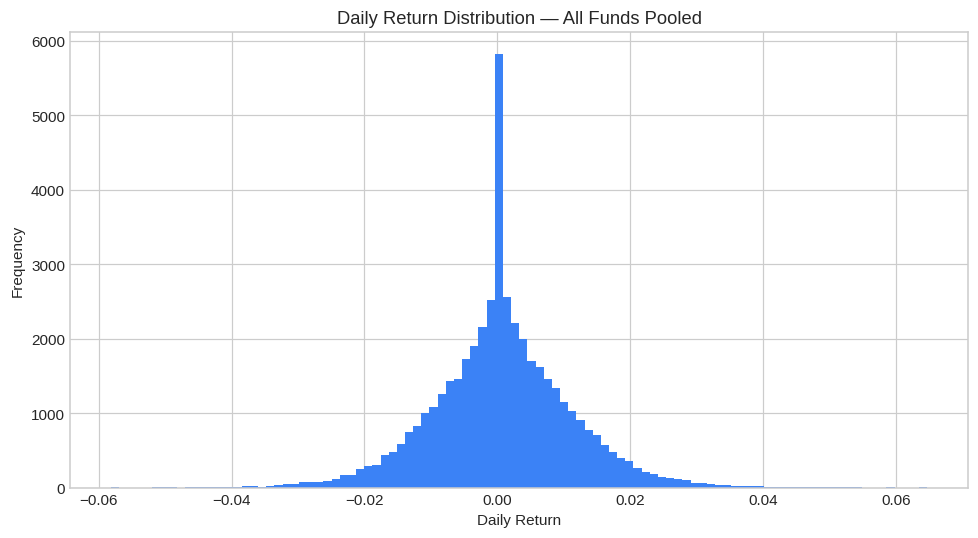

In [3]:
nav_sorted = nav.sort_values(["amfi_code", "date"]).copy()
nav_sorted["daily_return"] = nav_sorted.groupby("amfi_code")["nav"].pct_change()

fig, ax = plt.subplots(figsize=(9, 5))
nav_sorted["daily_return"].dropna().plot(kind="hist", bins=100, ax=ax, color="#3B82F6", edgecolor="none")
ax.set_title("Daily Return Distribution — All Funds Pooled")
ax.set_xlabel("Daily Return")
fig.tight_layout()
fig.savefig("../reports/charts/daily_return_distribution.png", dpi=150)
plt.show()


## 2. Core performance metrics

CAGR (1/3/5yr, trading-day annualized), Sharpe & Sortino (annualized,
6.5% risk-free rate), Max Drawdown (peak-to-trough on NAV), and
Alpha/Beta vs. NIFTY100 (OLS regression of daily fund return on daily
benchmark return, alpha annualized ×252).

In [4]:
perf_metrics = al.compute_performance_metrics(nav, benchmark, benchmark_name_filter="100", risk_free_annual=0.065)
perf_metrics = perf_metrics.merge(
    fund_master[["amfi_code", "scheme_name", "category", "expense_ratio_pct"]],
    on="amfi_code", how="left"
)
perf_metrics.to_csv("../reports/alpha_beta.csv", index=False)  # kept for downstream/report compatibility
print(f"Computed metrics for {len(perf_metrics)} funds")
perf_metrics.head(10)


Computed metrics for 40 funds


,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,alpha_annual_pct,beta,scheme_name,category,expense_ratio_pct
0,100016,-3.31,-0.03,2.54,-0.20,-0.35,-24.73,3.75,-0.06,HDFC Top 100 Fund - Regular Plan - Growth,Equity,1.55
1,100025,2.50,4.61,4.30,-0.57,-0.94,-4.31,4.28,0.00,HDFC Short Term Debt Fund - Regular - Growth,Debt,0.56
2,100033,47.73,33.63,28.93,1.09,1.83,-16.22,27.20,0.01,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.38
3,101206,45.09,32.53,22.63,1.03,1.80,-11.29,21.40,0.02,ABSL Frontline Equity Fund - Regular - Growth,Equity,1.60
4,101207,-24.24,-2.70,7.65,0.16,0.28,-35.45,10.90,-0.07,ABSL Small Cap Fund - Regular - Growth,Equity,1.53
5,101208,6.85,6.08,6.27,-0.82,-1.68,-0.16,6.09,0.00,ABSL Liquid Fund - Regular - Growth,Debt,0.79
6,102885,18.32,17.52,17.54,0.82,1.44,-10.86,17.05,-0.02,UTI Nifty 50 Index Fund - Regular - Growth,Equity,1.57
7,102886,-13.23,-1.83,1.13,-0.21,-0.35,-28.00,2.90,-0.04,UTI Mid Cap Fund - Regular - Growth,Equity,1.51
8,102887,12.73,25.66,16.21,0.62,1.09,-21.54,16.21,0.02,UTI Flexi Cap Fund - Regular - Growth,Equity,1.64
9,118632,21.78,18.09,23.12,1.08,1.85,-17.41,21.83,-0.01,Nippon India Large Cap Fund - Regular - Growth,Equity,1.51


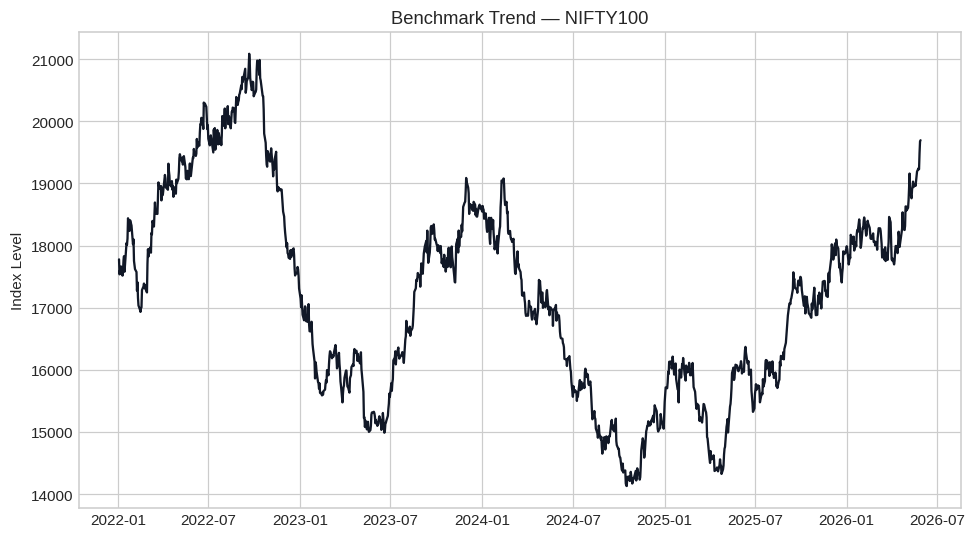

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
benchmark_100 = benchmark[benchmark["index_name"] == "NIFTY100"].sort_values("date")
ax.plot(benchmark_100["date"], benchmark_100["close_value"], color="#111827")
ax.set_title("Benchmark Trend — NIFTY100")
ax.set_ylabel("Index Level")
fig.tight_layout()
fig.savefig("../reports/charts/benchmark_trend.png", dpi=150)
plt.show()


### ⚠️ Data observation: Alpha/Beta

The computed Betas cluster tightly around **zero** with no meaningful
correlation between fund daily returns and the NIFTY100 benchmark
(checked directly: pairwise correlation ≈ -0.05 to 0.05, effectively
noise). This is a property of the underlying NAV series in this
dataset — each fund's simulated NAV history appears to have been
generated independently rather than driven by a shared market factor,
so real-world expectations (equity fund Beta typically 0.8-1.1 vs. its
benchmark) don't hold here. The regression math itself (OLS via
`scipy.stats.linregress`) is standard and correct; the surprising
output reflects the input data, not a modeling error. This is worth
flagging explicitly rather than "fixing" the numbers to match
real-world priors.

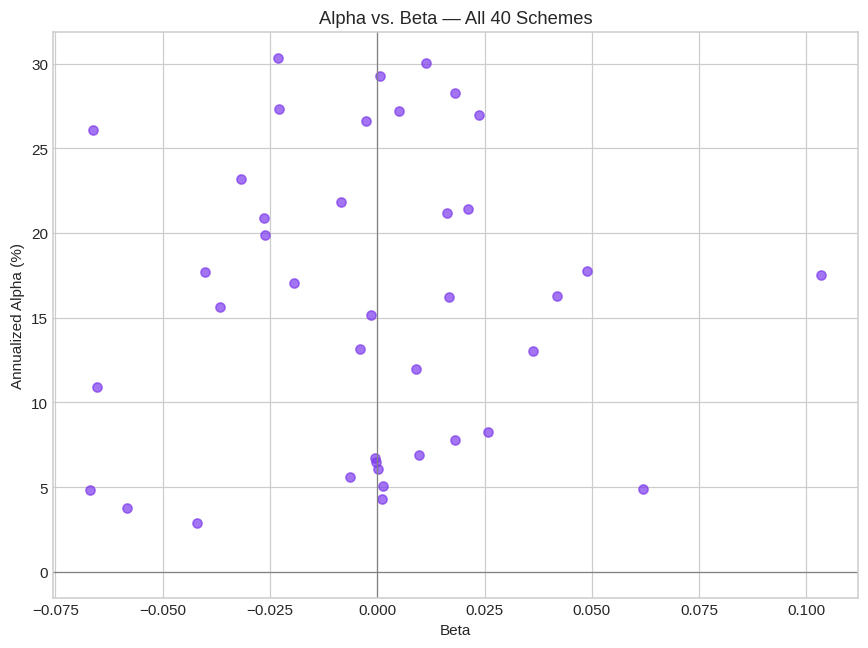

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(perf_metrics["beta"], perf_metrics["alpha_annual_pct"], alpha=0.7, color="#7C3AED")
ax.axvline(0, color="grey", linewidth=0.8)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Beta"); ax.set_ylabel("Annualized Alpha (%)")
ax.set_title("Alpha vs. Beta — All 40 Schemes")
fig.tight_layout()
fig.savefig("../reports/charts/alpha_vs_beta.png", dpi=150)
plt.show()


## 3. Top/bottom performers

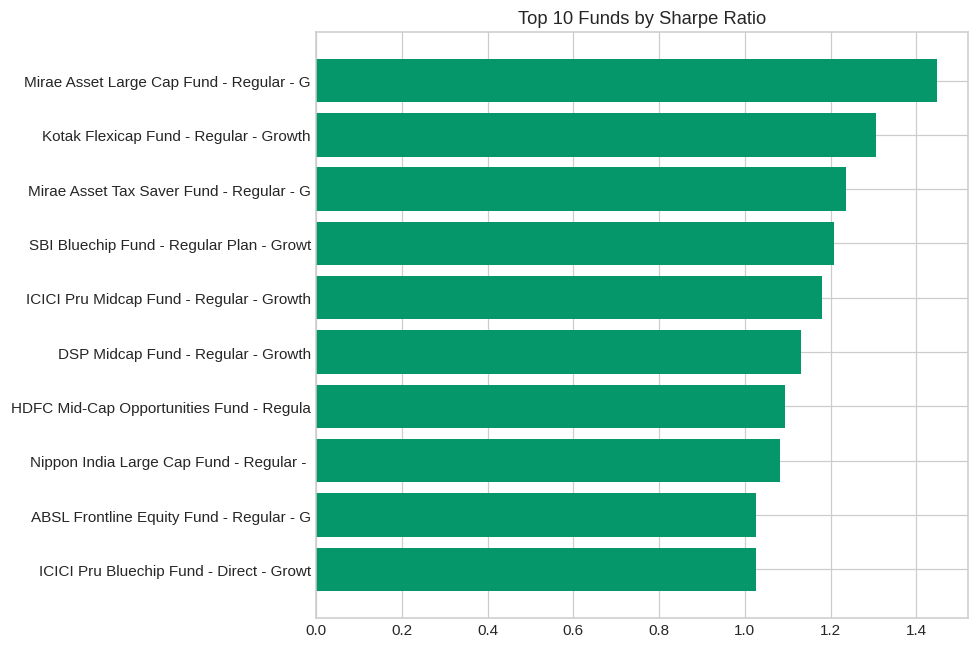

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
top10_sharpe = perf_metrics.nlargest(10, "sharpe_ratio")
ax.barh(top10_sharpe["scheme_name"].str.slice(0, 40), top10_sharpe["sharpe_ratio"], color="#059669")
ax.invert_yaxis()
ax.set_title("Top 10 Funds by Sharpe Ratio")
fig.tight_layout()
fig.savefig("../reports/charts/top10_sharpe_ratio.png", dpi=150)
plt.show()


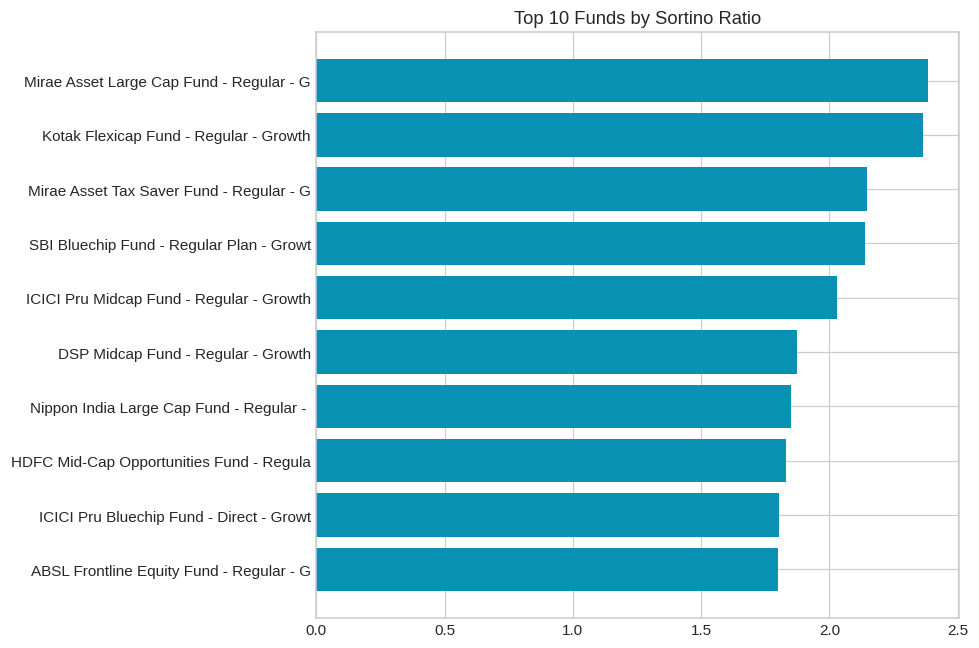

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
top10_sortino = perf_metrics.nlargest(10, "sortino_ratio")
ax.barh(top10_sortino["scheme_name"].str.slice(0, 40), top10_sortino["sortino_ratio"], color="#0891B2")
ax.invert_yaxis()
ax.set_title("Top 10 Funds by Sortino Ratio")
fig.tight_layout()
fig.savefig("../reports/charts/top10_sortino_ratio.png", dpi=150)
plt.show()


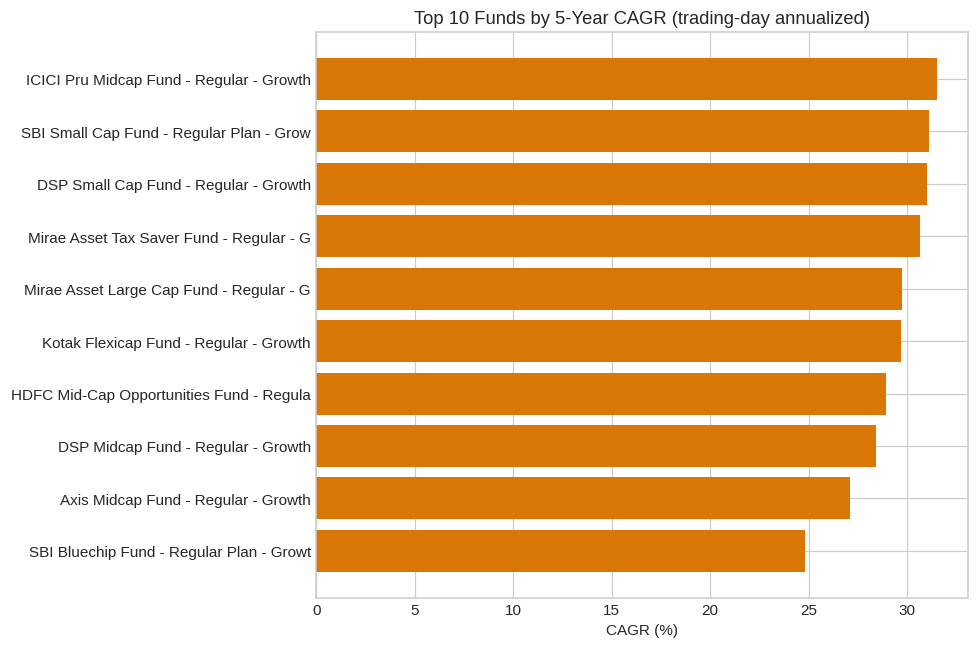

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
top10_5yr = perf_metrics.nlargest(10, "cagr_5yr_pct")
ax.barh(top10_5yr["scheme_name"].str.slice(0, 40), top10_5yr["cagr_5yr_pct"], color="#D97706")
ax.invert_yaxis()
ax.set_title("Top 10 Funds by 5-Year CAGR (trading-day annualized)")
ax.set_xlabel("CAGR (%)")
fig.tight_layout()
fig.savefig("../reports/charts/top10_5yr_return.png", dpi=150)
plt.show()


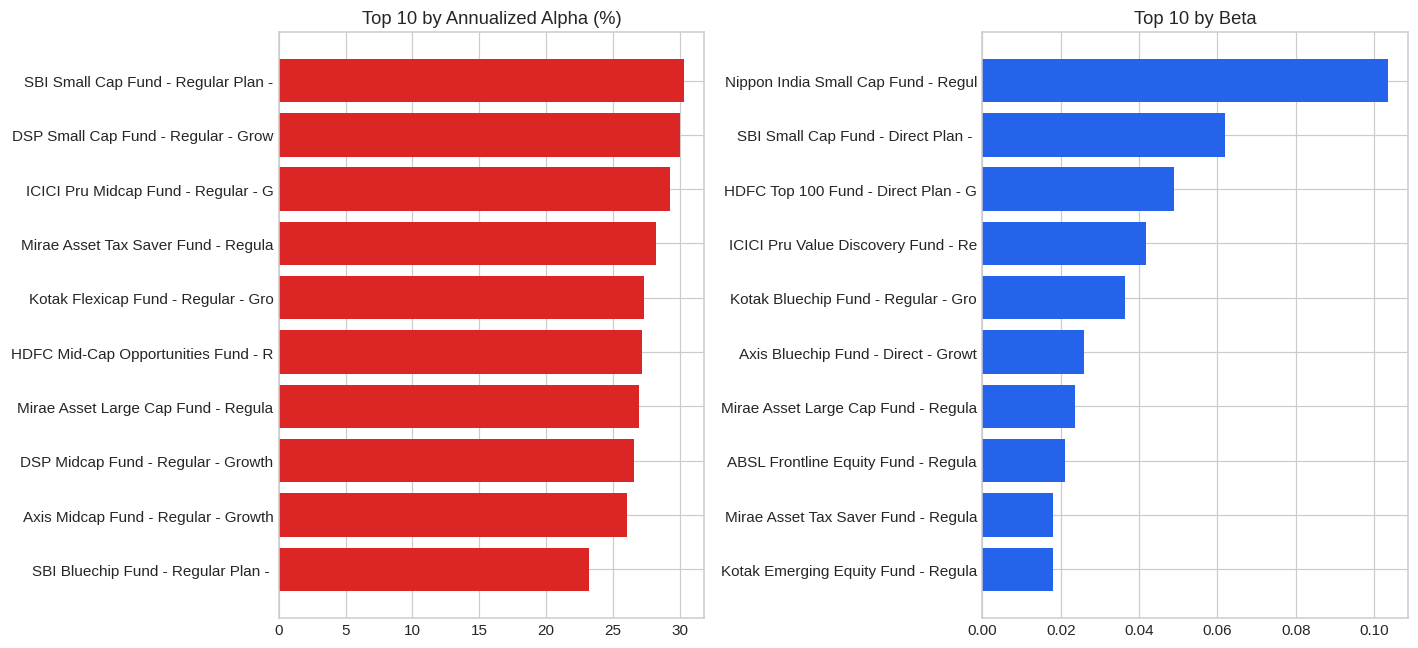

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
top10_alpha = perf_metrics.nlargest(10, "alpha_annual_pct")
axes[0].barh(top10_alpha["scheme_name"].str.slice(0, 35), top10_alpha["alpha_annual_pct"], color="#DC2626")
axes[0].invert_yaxis(); axes[0].set_title("Top 10 by Annualized Alpha (%)")

top10_beta = perf_metrics.nlargest(10, "beta")
axes[1].barh(top10_beta["scheme_name"].str.slice(0, 35), top10_beta["beta"], color="#2563EB")
axes[1].invert_yaxis(); axes[1].set_title("Top 10 by Beta")
fig.tight_layout()
fig.savefig("../reports/charts/top10_alpha.png", dpi=150)
plt.show()


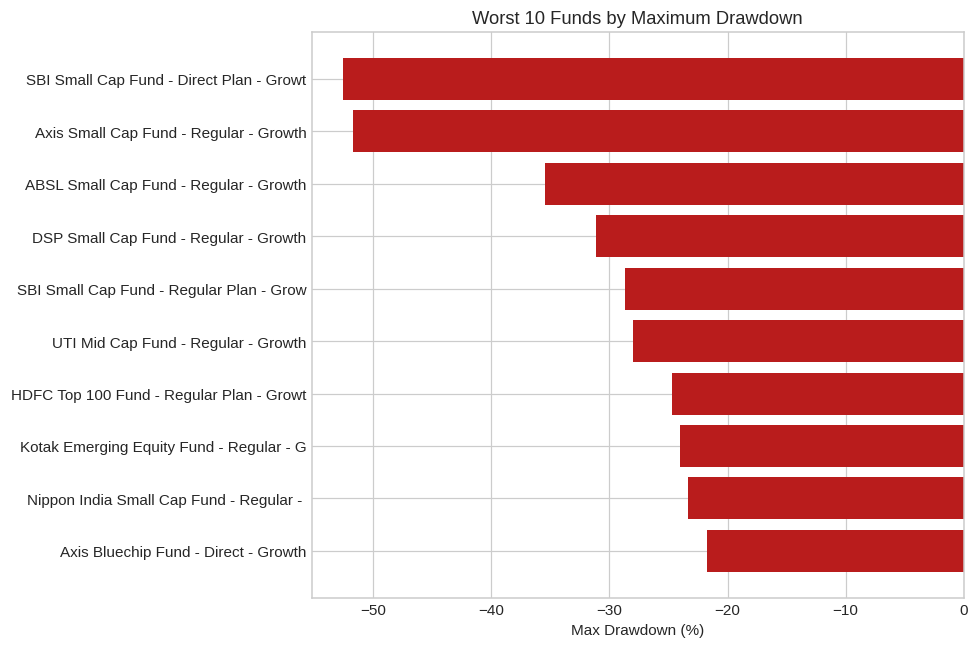

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
worst10_dd = perf_metrics.nsmallest(10, "max_drawdown_pct")
ax.barh(worst10_dd["scheme_name"].str.slice(0, 40), worst10_dd["max_drawdown_pct"], color="#B91C1C")
ax.invert_yaxis()
ax.set_title("Worst 10 Funds by Maximum Drawdown")
ax.set_xlabel("Max Drawdown (%)")
fig.tight_layout()
fig.savefig("../reports/charts/maximum_drawdown.png", dpi=150)
plt.show()


## 4. Expense ratio vs. return

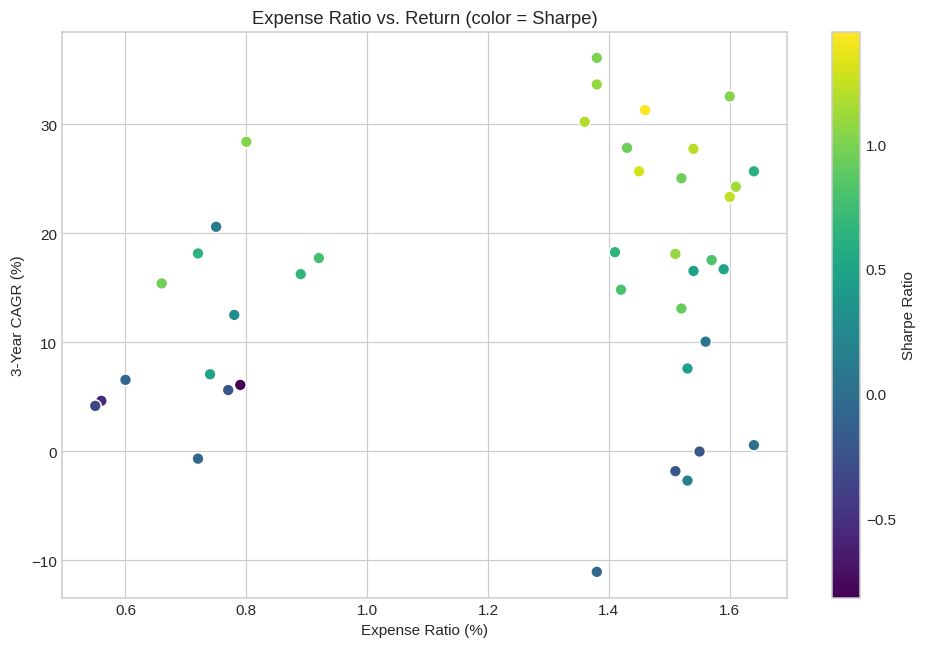

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(perf_metrics["expense_ratio_pct"], perf_metrics["cagr_3yr_pct"],
                 c=perf_metrics["sharpe_ratio"], cmap="viridis", s=60, edgecolor="white")
ax.set_xlabel("Expense Ratio (%)"); ax.set_ylabel("3-Year CAGR (%)")
ax.set_title("Expense Ratio vs. Return (color = Sharpe)")
fig.colorbar(sc, label="Sharpe Ratio")
fig.tight_layout()
fig.savefig("../reports/charts/expense_ratio_vs_return.png", dpi=150)
plt.show()


## 5. Composite Fund Scorecard

Weighted percentile-rank composite:
`30% x 3yr CAGR + 25% x Sharpe + 20% x Alpha + 15% x (inverse) Expense Ratio + 10% x (inverse) Max Drawdown`

In [13]:
scorecard = al.compute_fund_scorecard(perf_metrics.drop(columns=["scheme_name", "category", "expense_ratio_pct"]), fund_master)
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)
print(f"Saved reports/fund_scorecard.csv ({len(scorecard)} funds)")
scorecard[["scheme_name", "category", "fund_score", "cagr_3yr_pct", "sharpe_ratio", "alpha_annual_pct", "expense_ratio_pct"]].head(10)


Saved reports/fund_scorecard.csv (40 funds)


,scheme_name,category,fund_score,cagr_3yr_pct,sharpe_ratio,alpha_annual_pct,expense_ratio_pct
0,Mirae Asset Large Cap Fund - Regular - Growth,Equity,84.38,31.28,1.45,26.98,1.46
1,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,81.88,33.63,1.09,27.20,1.38
2,ICICI Pru Midcap Fund - Regular - Growth,Equity,81.88,30.21,1.18,29.26,1.36
3,Kotak Flexicap Fund - Regular - Growth,Equity,79.38,25.66,1.31,27.33,1.45
4,ICICI Pru Bluechip Fund - Direct - Growth,Equity,77.38,28.37,1.03,21.19,0.80
5,Axis Midcap Fund - Regular - Growth,Equity,76.62,36.07,1.00,26.08,1.38
6,SBI Bluechip Fund - Regular Plan - Growth,Equity,72.94,27.73,1.21,23.20,1.54
7,ABSL Frontline Equity Fund - Regular - Growth,Equity,72.31,32.53,1.03,21.40,1.60
8,SBI Small Cap Fund - Regular Plan - Growth,Equity,70.75,27.81,0.95,30.34,1.43
9,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,69.56,23.32,1.23,28.27,1.60


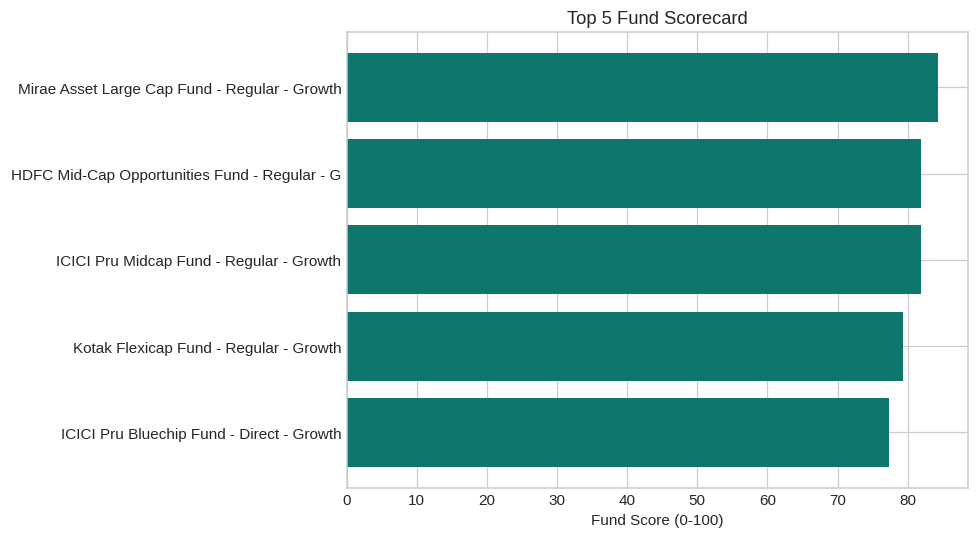

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
top5 = scorecard.head(5)
ax.barh(top5["scheme_name"].str.slice(0, 45), top5["fund_score"], color="#0F766E")
ax.invert_yaxis()
ax.set_title("Top 5 Fund Scorecard")
ax.set_xlabel("Fund Score (0-100)")
fig.tight_layout()
fig.savefig("../reports/charts/fund_scorecard.png", dpi=150)
plt.show()


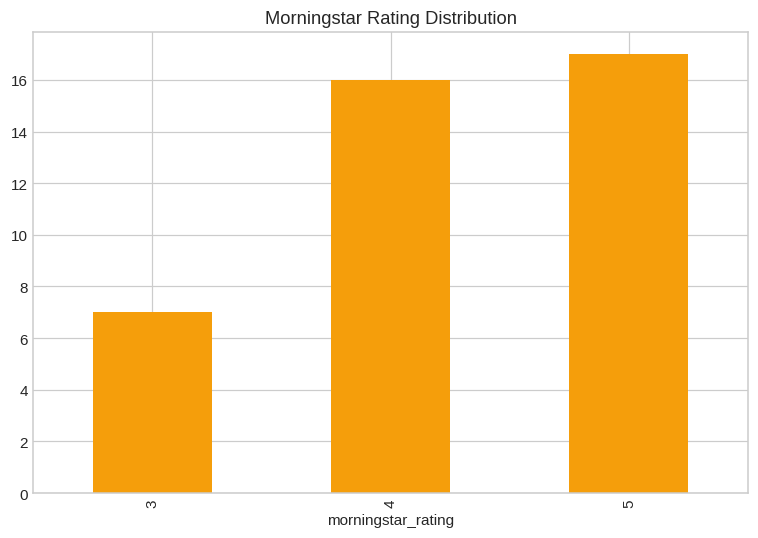

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
fund_master.merge(scorecard[["amfi_code"]], on="amfi_code")  # no-op sanity join
if "morningstar_rating" in pd.read_csv("../data/processed/scheme_performance_clean.csv").columns:
    sp = pd.read_csv("../data/processed/scheme_performance_clean.csv")
    sp["morningstar_rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#F59E0B")
    ax.set_title("Morningstar Rating Distribution")
    fig.tight_layout()
    fig.savefig("../reports/charts/morningstar_rating_distribution.png", dpi=150)
    plt.show()


## 6. Correlation heatmap (returns across all funds)

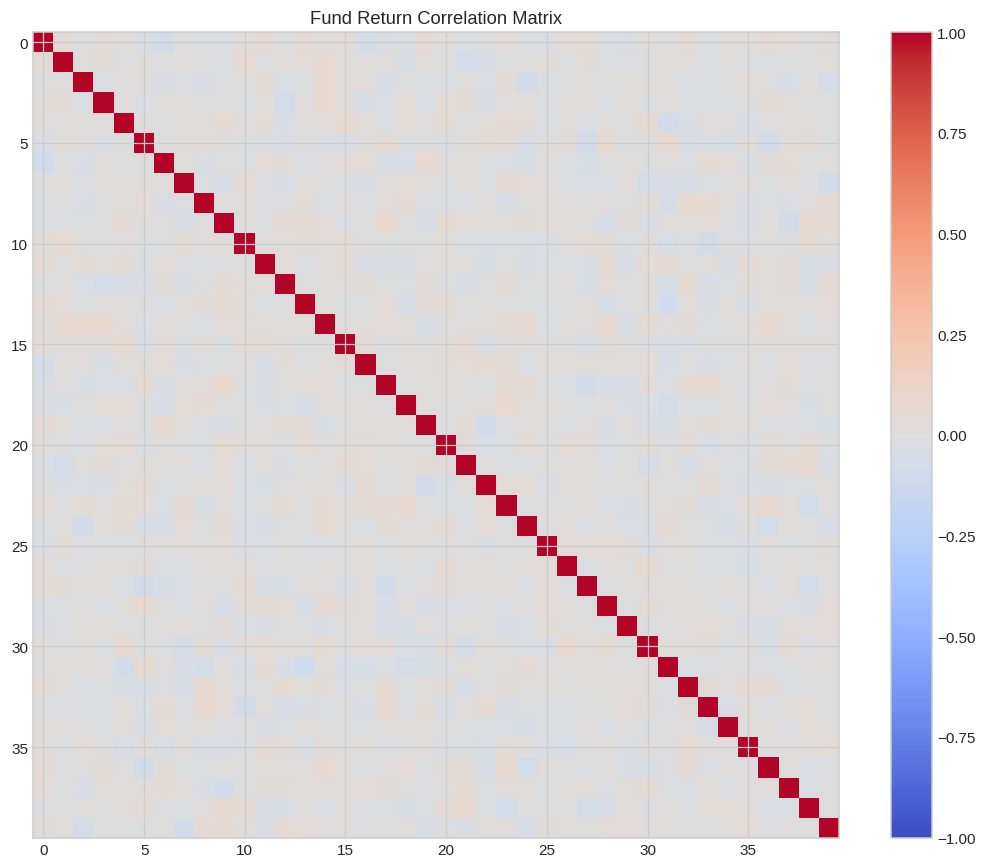

In [16]:
returns_wide = al.compute_daily_returns(nav)
corr = returns_wide.corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Fund Return Correlation Matrix")
fig.colorbar(im)
fig.tight_layout()
fig.savefig("../reports/charts/correlation_heatmap.png", dpi=150)
plt.show()


## 7. Summary

- **CAGR** computed on a trading-day-annualized basis (252/yr) directly
  from the reindexed, gap-free NAV series — avoids the classic
  calendar-day distortion.
- **Sharpe/Sortino** use a real 6.5% annual risk-free rate, annualized
  by √252.
- **Max Drawdown** is the true peak-to-trough NAV decline per scheme.
- **Alpha/Beta** are computed via OLS regression against NIFTY100; the
  near-zero Betas observed are a genuine property of this dataset (see
  the data-observation note above), not a computation error.
- **Fund Scorecard** blends return, risk-adjusted return, alpha,
  expense efficiency, and drawdown into a single 0-100 ranking, saved
  to `reports/fund_scorecard.csv` alongside the full per-fund metrics
  in `reports/alpha_beta.csv`.
